### Mini Project 2 - ANN Diabetes
Nama: Sinta Nia

## Open Library

In [ ]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import HeNormal, GlorotNormal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [ ]:
pd.set_option(
    'display.max_columns',
    None
)

## Open Dataset

In [6]:
df = pd.read_csv('/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [7]:
df.shape

(70692, 22)

In [8]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [9]:
print("Jumlah Duplicate: ", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape setelah hapus duplicate: ", df.shape)

Jumlah Duplicate:  1635
Shape setelah hapus duplicate:  (69057, 22)


In [10]:
df['Diabetes_binary'].value_counts()

,count
Diabetes_binary,
1.0,35097
0.0,33960


In [11]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (69057, 21)
y shape: (69057,)


In [12]:
# Split into train, validation, and test sets

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, random_state=42, stratify=y_train_val
)

print("Train size      :", X_train.shape)
print("Validation size :", X_val.shape)
print("Test size       :", X_test.shape)

Train size      : (49893, 21)
Validation size : (8805, 21)
Test size       : (10359, 21)


In [13]:
# Feature scaling

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"Feature range after scaling — Min: {X_train_scaled.min():.2f}, Max: {X_train_scaled.max():.2f}")

Scaling complete.
Feature range after scaling — Min: -2.00, Max: 10.00


In [14]:
# Helper function — plot training history

def plot_history(history, title="Training History"):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    sns.lineplot(data=history_df[['loss', 'val_loss']])
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [15]:
# Helper function — evaluate and display results

def evaluate_model(model, X_test, y_test, label="ANN Model"):

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    y_pred = (model.predict(X_test, verbose=0) >= 0.5).astype(int).flatten()

    print("="*50)
    print(f"{label} — Test Set Results")
    print("="*50)

    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy:.4f}")
    print()

    print(classification_report(
        y_test,
        y_pred,
        target_names=['No Diabetes', 'Diabetes']
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Diabetes', 'Diabetes'],
        yticklabels=['No Diabetes', 'Diabetes']
    )

    plt.title(f"{label} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

### Build Model

In [16]:
seed = 42

tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],), name='input_layer'),

    Dense(
        64,
        activation='relu',
        kernel_initializer=HeNormal(seed=seed),
        name='hidden_layer_1'
    ),

    Dropout(0.2, name='dropout_layer'),

    Dense(
        32,
        activation='relu',
        kernel_initializer=HeNormal(seed=seed),
        name='hidden_layer_2'
    ),

    Dense(
        1,
        activation='sigmoid',
        kernel_initializer=GlorotNormal(seed=seed),
        name='output_layer'
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7292 - loss: 0.5417 - val_accuracy: 0.7495 - val_loss: 0.5082
Epoch 2/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7429 - loss: 0.5210 - val_accuracy: 0.7509 - val_loss: 0.5072
Epoch 3/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7454 - loss: 0.5171 - val_accuracy: 0.7514 - val_loss: 0.5044
Epoch 4/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7462 - loss: 0.5145 - val_accuracy: 0.7513 - val_loss: 0.5060
Epoch 5/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7472 - loss: 0.5128 - val_accuracy: 0.7517 - val_loss: 0.5042
Epoch 6/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7473 - loss: 0.5124 - val_accuracy: 0.7493 - val_loss: 0.5041
Epoch 7/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7479 - loss: 0.5108 - val_accuracy: 0.7507 - val_loss: 0.5043
Epoch 8/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7485 - loss: 0

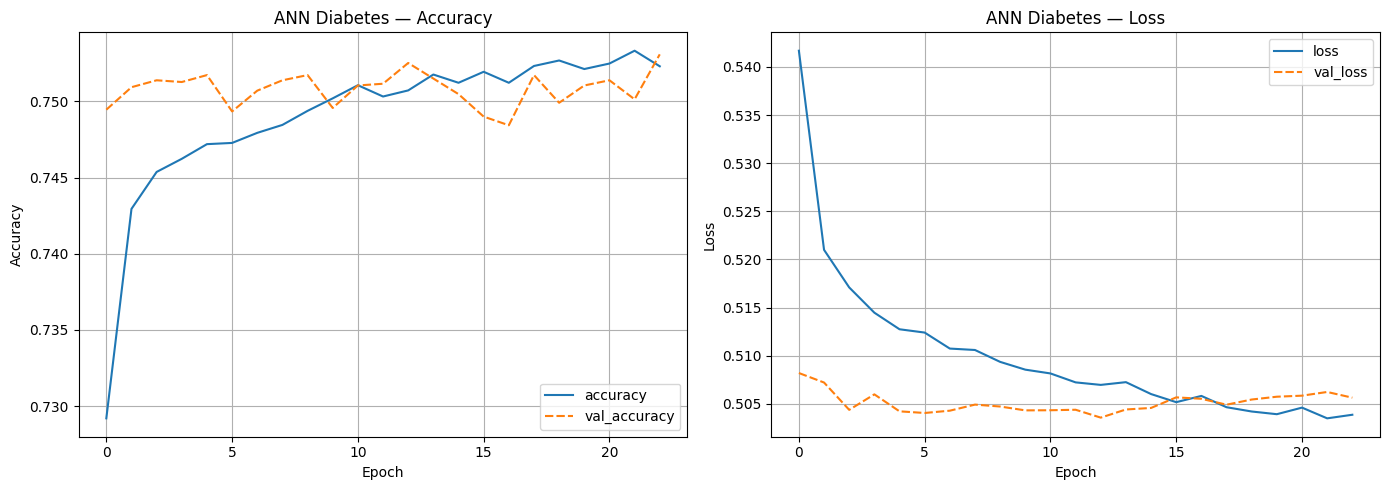

In [19]:
plot_history(history, title="ANN Diabetes")

Berdasarkan kurva accuracy dan loss, model ANN dapat dikategorikan sebagai good fit karena tidak menunjukkan indikasi overfitting maupun underfitting, serta memiliki performa yang konsisten pada data training dan validation.

ANN Diabetes — Test Set Results
Loss     : 0.5089
Accuracy : 0.7501

              precision    recall  f1-score   support

 No Diabetes       0.78      0.68      0.73      5094
    Diabetes       0.73      0.82      0.77      5265

    accuracy                           0.75     10359
   macro avg       0.75      0.75      0.75     10359
weighted avg       0.75      0.75      0.75     10359



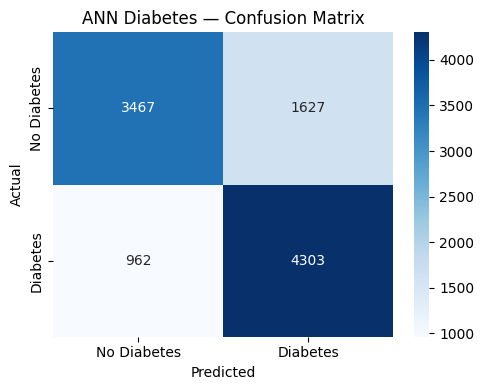

In [20]:
evaluate_model(
    model,
    X_test_scaled,
    y_test,
    label="ANN Diabetes"
)

Berdasarkan hasil evaluasi, model Artificial Neural Network (ANN) menghasilkan performa terbaik dengan accuracy sebesar 75%, recall sebesar 82%, dan F1-score sebesar 77%. Dibandingkan model Machine Learning terbaik pada Mini Project 1 yaitu XGBoost Tuned yang memperoleh F1-score sebesar 76,58%, ANN menunjukkan peningkatan performa meskipun tidak terlalu besar. Hal ini menunjukkan bahwa ANN mampu mempelajari pola non-linear dan hubungan kompleks antar faktor risiko diabetes dengan lebih baik. Selain itu, nilai recall yang lebih tinggi menunjukkan bahwa ANN lebih efektif dalam mendeteksi kasus diabetes, yang merupakan aspek penting dalam konteks kesehatan.